In [ ]:
pwd

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob

In [3]:
ec_lookup = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/A10_sequencing/v2/current/analysis2_updated.db'
rptr_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb'
ad_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb'
ec_output = 'test_1_15_merge.db'

# Drafting

In [1]:
def filter_and_group(db_path, is_rptr=True): # renamed to bc_grouping in TREBLseq_analysis
    try:
        conn = duckdb.connect(db_path)

        if is_rptr:
            group_query = f"""
                SELECT Barcode, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode
            """
            new_table = "rptr_summary"
        else:
            group_query = f"""
                SELECT Barcode, Tile, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode, Tile
            """
            new_table = "ad_summary"

        conn.execute(f"CREATE OR REPLACE TABLE {new_table} AS {group_query}")
        row_count = conn.execute(f"SELECT COUNT(*) FROM {new_table}").fetchone()[0]
        print(f"[GROUP] Wrote {row_count} rows to {new_table} in {db_path}")

    except Exception as e:
        print(f"[ERROR] While filtering and grouping {db_path}: {e}")

    finally:
        conn.close()


def perform_lookup(rptr_db_path, lookup_db_path):
    try:
        rptr_conn = duckdb.connect(rptr_db_path)
        rptr_conn.execute(f"ATTACH DATABASE '{lookup_db_path}' AS lookup_db")

        total_rptr_barcodes = rptr_conn.execute("SELECT COUNT(*) FROM rptr_summary").fetchone()[0]

        rptr_conn.execute("""
            CREATE OR REPLACE TABLE rptr_lookup_joined AS
            SELECT 
                r.Barcode, r.UMIs, r.Reads,
                l.AD,
                l.AD_BC,
                l.AD || '-' || l.AD_BC AS AD_ADBC
            FROM rptr_summary r
            INNER JOIN lookup_db.A10_2_T_NODBLMAP_20240422 l
            ON r.Barcode = l.RPTR_BC;
        """)

        matched_count = rptr_conn.execute("SELECT COUNT(*) FROM rptr_lookup_joined").fetchone()[0]
        print(f"[LOOKUP JOIN] Matched {matched_count} of {total_rptr_barcodes} RPTR barcodes "
              f"({total_rptr_barcodes - matched_count} unmatched, discarded in join).")

    except Exception as e:
        print(f"[ERROR] During lookup join in {rptr_db_path}: {e}")

    finally:
        rptr_conn.close()


def join_rptr_ad(rptr_db, ad_db, output_db):
    try:
        conn_out = duckdb.connect(output_db)

        # Attach RPTR and AD databases
        conn_out.execute(f"ATTACH DATABASE '{rptr_db}' AS rptr_db")
        conn_out.execute(f"ATTACH DATABASE '{ad_db}' AS ad_db")

        # Perform join and save
        conn_out.execute("""
            CREATE OR REPLACE TABLE final_analysis AS
            SELECT 
                r.Barcode AS RPTR_BC,
                r.UMIs AS RPTR_UMIs,
                r.Reads AS RPTR_Reads,
                a.Barcode AS AD_BC,
                a.Tile,
                a.UMIs AS AD_UMIs,
                a.Reads AS AD_Reads
            FROM rptr_db.rptr_lookup_joined r
            INNER JOIN ad_db.ad_summary a
            ON r.AD_ADBC = a.Tile || '-' || a.Barcode;
        """)

        joined_count = conn_out.execute("SELECT COUNT(*) FROM final_analysis").fetchone()[0]
        print(f"[JOIN FINAL] Joined entries: {joined_count}")

    except Exception as e:
        print(f"[ERROR] During final join: {e}")

    finally:
        conn_out.close()



In [6]:
# # did the filtering --> these were overwritten
# filter_and_group(rptr_1_15, is_rptr=True) # 731833 rows to rptr_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb
# filter_and_group(ad_1_15, is_rptr=False) # 1,120,038 rows to ad_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb

In [7]:
# took out the filtering = 2 Million barcodes each
# filter_and_group(rptr_1_15, is_rptr=True) # 2,783,623 rows to rptr_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb
filter_and_group(ad_1_15, is_rptr=False) # 2,761,835 rows to ad_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb

[GROUP] Wrote 2761835 rows to ad_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb


In [8]:
perform_lookup(rptr_1_15, ec_lookup)
join_rptr_ad(rptr_1_15, ad_1_15, ec_output)

[LOOKUP JOIN] Matched 18194 of 2783623 RPTR barcodes (2765429 unmatched, discarded in join).
[JOIN FINAL] Joined entries: 16376


In [49]:
join_rptr_ad(rptr_1_15, ad_1_15, ec_output)

[JOIN FINAL] Joined entries: 16376


# Testing

### RPTR DBs

In [3]:
connR = duckdb.connect(rptr_1_15)
connR.sql("SHOW ALL TABLES")

┌─────────────────────┬─────────┬────────────────────┬────────────────────────────────────────────┬───────────────────────────────────────────────────────┬───────────┐
│      database       │ schema  │        name        │                column_names                │                     column_types                      │ temporary │
│       varchar       │ varchar │      varchar       │                 varchar[]                  │                       varchar[]                       │  boolean  │
├─────────────────────┼─────────┼────────────────────┼────────────────────────────────────────────┼───────────────────────────────────────────────────────┼───────────┤
│ RPTR_1_15_S4_R1_001 │ main    │ rptr_lookup_joined │ [Barcode, UMIs, Reads, AD, AD_BC, AD_ADBC] │ [VARCHAR, BIGINT, HUGEINT, VARCHAR, VARCHAR, VARCHAR] │ false     │
│ RPTR_1_15_S4_R1_001 │ main    │ rptr_summary       │ [Barcode, UMIs, Reads]                     │ [VARCHAR, BIGINT, HUGEINT]                            │ fals

In [7]:
connR.sql("SELECT * FROM rptr_summary LIMIT 5")

┌────────────────┬────────┬──────────┐
│    Barcode     │  UMIs  │  Reads   │
│    varchar     │ int64  │  int128  │
├────────────────┼────────┼──────────┤
│ TAAAGCGCCGGAGC │     97 │     5970 │
│ ACTTCTAAATAAGC │ 313416 │ 18637738 │
│ CTGACTCAATACAA │    116 │     6544 │
│ GTCCAGTTTAGTGA │  19662 │  1058210 │
│ TTCATCAATTCGAC │   5607 │   301372 │
└────────────────┴────────┴──────────┘

In [18]:
connR.sql("SELECT * FROM rptr_lookup_joined LIMIT 5")

┌────────────────┬───────┬────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│    Barcode     │ UMIs  │ Reads  │                                                            AD                                                            │    AD_BC    │                                                               AD_ADBC                                                                │
│    varchar     │ int64 │ int128 │                                                         varchar                                                          │   varchar   │                                                               varchar                                                                │
├────────────────┼───────┼────────┼─────────────────────────────────────────

In [22]:
connR.sql("SELECT COUNT(DISTINCT AD) FROM rptr_lookup_joined").fetchone()[0]

11611

In [4]:
RPTR_1_15_df = connR.sql("SELECT * FROM rptr_summary").df()
RPTR_1_15_df

,Barcode,UMIs,Reads
0,ACTTCTAAATAAGC,313416,18637738.0
1,AGCCTTAAGTTTCA,5263,276681.0
2,TGTTATTAAGCGGG,2299,118464.0
3,GCATTTGTTAGCAT,2754,151636.0
4,GTCGCCGTACGGAC,4324,226480.0
...,...,...,...
2783618,CGCGCCAACAAGGA,1,1.0
2783619,CTTCCTCGCAAATG,1,1.0
2783620,GAATCGCAGGGTTC,1,1.0
2783621,GGCGTAAGGAAAAA,1,1.0


In [27]:
RPTR_1_15_df.describe()

,UMIs,Reads
count,2.783623e+06,2.783623e+06
mean,6.512368e+00,1.721533e+02
std,2.507367e+02,1.326380e+04
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,2.000000e+00,2.000000e+00
max,3.134160e+05,1.863774e+07


In [5]:
RPTR_1_15_df[RPTR_1_15_df['Reads']>50]

,Barcode,UMIs,Reads
0,ACTTCTAAATAAGC,313416,18637738.0
1,AGCCTTAAGTTTCA,5263,276681.0
2,TGTTATTAAGCGGG,2299,118464.0
3,GCATTTGTTAGCAT,2754,151636.0
4,GTCGCCGTACGGAC,4324,226480.0
...,...,...,...
2780804,ACACCTCTAATTAG,1,94.0
2780812,CATTGGTTCATCTC,1,115.0
2780866,GAGCTGTTCCTGAT,1,112.0
2780881,CAAGAGGACCCGCG,1,139.0


/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'UMIs per RPTR Barcode')

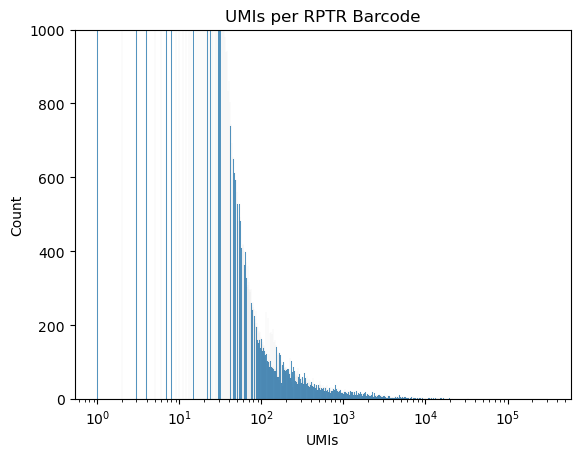

In [38]:
sns.histplot(RPTR_1_15_df, x='UMIs', log_scale=True)
plt.ylim(0,1000)
plt.title("UMIs per RPTR Barcode")

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Reads per RPTR Barcode')

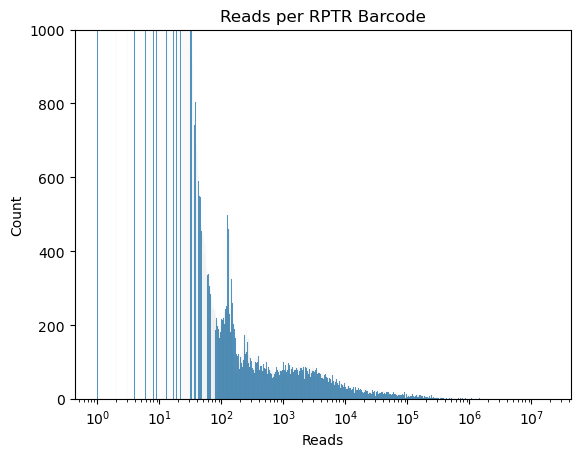

In [37]:
sns.histplot(RPTR_1_15_df, x='Reads', log_scale=True)
plt.ylim(0,1000)
# plt.xlim(80,10e7)
plt.title("Reads per RPTR Barcode")

In [39]:
connR.close()

### Merged DBs

In [7]:
ls

AD_UMIdemultiplexed/    Untitled.ipynb   logs/  test_1_15_merge.db
RPTR_UMIdemultiplexed/  debugging.ipynb  old/


In [6]:
conntest = duckdb.connect(ec_output)
conntest.sql("SHOW ALL TABLES")

┌─────────────────┬─────────┬────────────────┬──────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────┬───────────┐
│    database     │ schema  │      name      │                           column_names                           │                         column_types                          │ temporary │
│     varchar     │ varchar │    varchar     │                            varchar[]                             │                           varchar[]                           │  boolean  │
├─────────────────┼─────────┼────────────────┼──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┼───────────┤
│ test_1_15_merge │ main    │ final_analysis │ [RPTR_BC, RPTR_UMIs, RPTR_Reads, AD_BC, Tile, AD_UMIs, AD_Reads] │ [VARCHAR, BIGINT, HUGEINT, VARCHAR, VARCHAR, BIGINT, HUGEINT] │ false     │
└─────────────────┴─────────┴────────────────┴────

In [5]:
conntest.sql("SELECT * FROM final_analysis LIMIT 3")

┌────────────────┬───────────┬────────────┬─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┬──────────┐
│    RPTR_BC     │ RPTR_UMIs │ RPTR_Reads │    AD_BC    │                                                           Tile                                                           │ AD_UMIs │ AD_Reads │
│    varchar     │   int64   │   int128   │   varchar   │                                                         varchar                                                          │  int64  │  int128  │
├────────────────┼───────────┼────────────┼─────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┼──────────┤
│ ACTTAGTGGGTATC │       113 │       5637 │ TATAGAATTAC │ GTTCAAGATTCTCCAGCTGAAGCTTCTGATGAAGTTGAAACTGGTCCAGATGCTTCTCCAGCTCCAACTAGAAGGAAATCTGGTGGTTCTCCAGGTGCTGGTAGACATTCTTCTGTTGCT │     860 │  

In [6]:
conntest.sql("SELECT COUNT(DISTINCT Tile) FROM final_analysis")

┌──────────────────────┐
│ count(DISTINCT Tile) │
│        int64         │
├──────────────────────┤
│                10925 │
└──────────────────────┘

In [7]:
merged_1_15_df = conntest.sql("SELECT * FROM final_analysis").df()
merged_1_15_df

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads
0,ACTTAGTGGGTATC,113,5637.0,TATAGAATTAC,GTTCAAGATTCTCCAGCTGAAGCTTCTGATGAAGTTGAAACTGGTC...,860,11407.0
1,TTACAATAGACTCT,3551,203926.0,CCGTAGGTTAA,TTTGATTTGGTTGGTGAAGAAGGTGCTGGTAAACCATTGTCTCAAT...,954,12346.0
2,CTCCTAGCCACATA,180,9289.0,AAGCGACAACA,CAAGATCCATATATGTCTGCTCCAAATTCTACTGCATTTACTGCTT...,74,1092.0
3,ATGAGTCCATTTCA,100,4895.0,TTTCCCTTCTG,GCTAGACCACCAGTTCCACCATTTCCACATTCTACTGGTTCTGTTC...,182,2380.0
4,CGGCACCATCTGGA,163,8862.0,GCCCCCGTCAC,TTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAAT...,1549,19854.0
...,...,...,...,...,...,...,...
16371,TGTACGGTTGTTCG,2,98.0,TAACCATTGTT,CATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTGTTAGATCTA...,2,22.0
16372,CTCACCCGGTGAAA,19,1183.0,GACGCCGGCGG,TTGGGTTATGCTACTTCTCCAGCTTCATTCTCTTATAGATCTCCAT...,4,4.0
16373,TCAAAACTGAATTA,7,367.0,TACGTGAACAA,CCAACTCATTCTGGTGCTAGAATTTCTACTGTTCCACAACCACCAC...,5,63.0
16374,CACTCCCGTATCAT,19,597.0,CATTGACATCG,TGGCCATCTCCACCAGCTCCACAACCATCTAGACATCATTTGAATA...,1,34.0


/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge UMIs per RPTR BC')

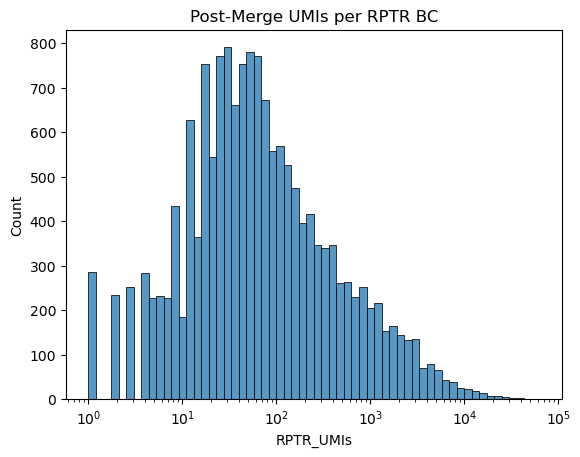

In [12]:
sns.histplot(merged_1_15_df, x='RPTR_UMIs', log_scale=True)
plt.title('Post-Merge UMIs per RPTR BC')

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge Reads per RPTR BC')

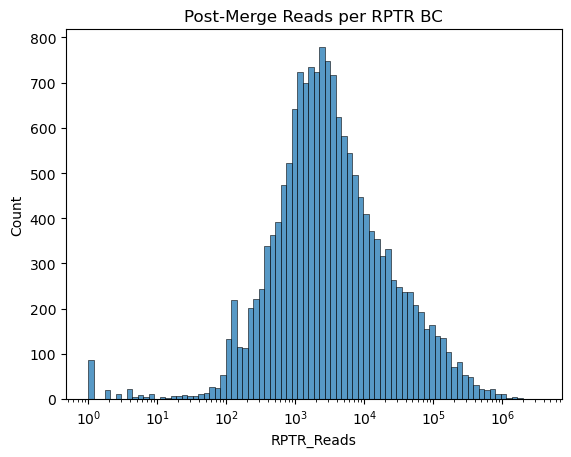

In [13]:
sns.histplot(merged_1_15_df, x='RPTR_Reads', log_scale=True)
plt.title('Post-Merge Reads per RPTR BC')

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge UMIs per Tile-Barcode Pair')

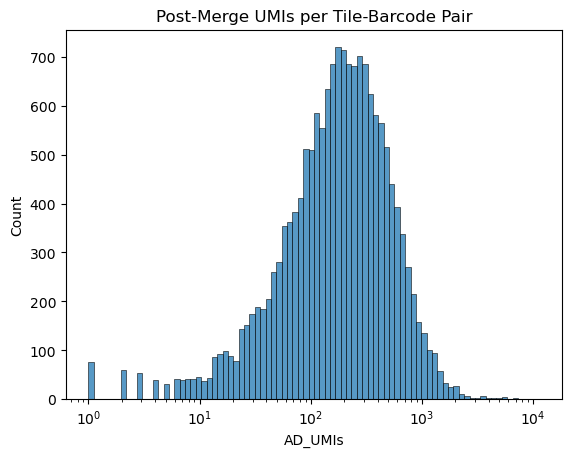

In [14]:
sns.histplot(merged_1_15_df, x='AD_UMIs', log_scale=True)
plt.title('Post-Merge UMIs per Tile-Barcode Pair')

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge Reads per Tile-Barcode Pair')

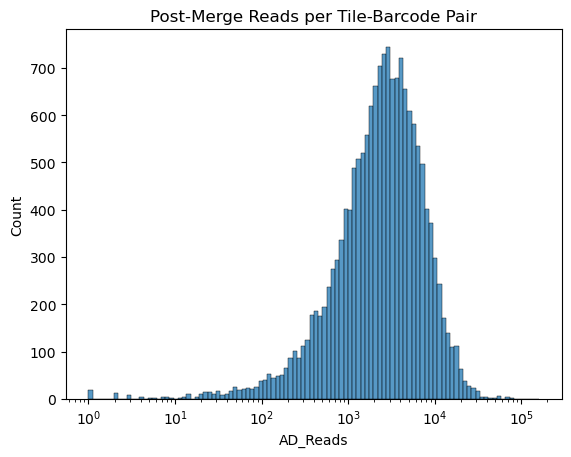

In [15]:
sns.histplot(merged_1_15_df, x='AD_Reads', log_scale=True)
plt.title('Post-Merge Reads per Tile-Barcode Pair')

In [8]:
merged_1_15_df['Ratio'] = merged_1_15_df['RPTR_UMIs'] / merged_1_15_df['AD_UMIs']

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge Ratios (RPTR_UMI/AD_UMI)')

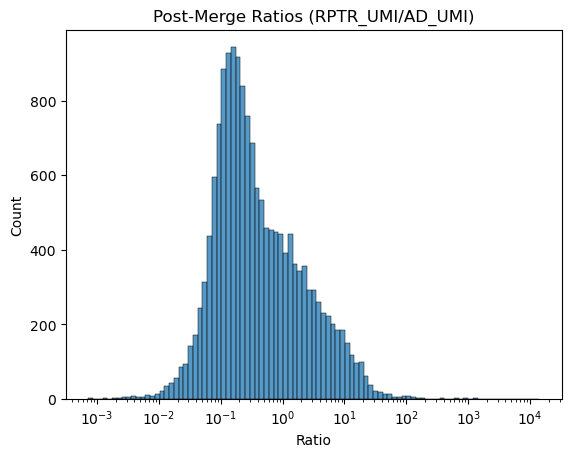

In [16]:
sns.histplot(merged_1_15_df, x='Ratio', log_scale=True)
plt.title('Post-Merge Ratios (RPTR_UMI/AD_UMI)')

In [9]:
conntest.close()

In [10]:
merged_1_15_df

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio
0,ACTTAGTGGGTATC,113,5637.0,TATAGAATTAC,GTTCAAGATTCTCCAGCTGAAGCTTCTGATGAAGTTGAAACTGGTC...,860,11407.0,0.131395
1,TTACAATAGACTCT,3551,203926.0,CCGTAGGTTAA,TTTGATTTGGTTGGTGAAGAAGGTGCTGGTAAACCATTGTCTCAAT...,954,12346.0,3.722222
2,CTCCTAGCCACATA,180,9289.0,AAGCGACAACA,CAAGATCCATATATGTCTGCTCCAAATTCTACTGCATTTACTGCTT...,74,1092.0,2.432432
3,ATGAGTCCATTTCA,100,4895.0,TTTCCCTTCTG,GCTAGACCACCAGTTCCACCATTTCCACATTCTACTGGTTCTGTTC...,182,2380.0,0.549451
4,CGGCACCATCTGGA,163,8862.0,GCCCCCGTCAC,TTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAAT...,1549,19854.0,0.105229
...,...,...,...,...,...,...,...,...
16371,TGTACGGTTGTTCG,2,98.0,TAACCATTGTT,CATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTGTTAGATCTA...,2,22.0,1.000000
16372,CTCACCCGGTGAAA,19,1183.0,GACGCCGGCGG,TTGGGTTATGCTACTTCTCCAGCTTCATTCTCTTATAGATCTCCAT...,4,4.0,4.750000
16373,TCAAAACTGAATTA,7,367.0,TACGTGAACAA,CCAACTCATTCTGGTGCTAGAATTTCTACTGTTCCACAACCACCAC...,5,63.0,1.400000
16374,CACTCCCGTATCAT,19,597.0,CATTGACATCG,TGGCCATCTCCACCAGCTCCACAACCATCTAGACATCATTTGAATA...,1,34.0,19.000000


In [12]:
# negative controls
negctrls_fpath = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/Ciber2_iii/CZB_Sep2024/neg_controls.csv'
neg_controls_df = pd.read_csv(negctrls_fpath, usecols=['DNAseq'])
neg_controls = neg_controls_df['DNAseq'].to_list() # list of all negative controls
neg_controls[:5]

['GATGCTTTGTCTTCTTCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCT',
 'TCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCTAGACAATTGTTGGAA',
 'TTGAATGCTTATAGAGAAAAAGGTGGTTGTGTTTTGTTGATTCATAGAGATACTAAACAAGTTGTTGAATATTTGTTGCAAGATAAAACTAGACCAGCTTATAGAGAAGATATTGAAGAT',
 'GCTTTGCATAATACTTTGTTTCAATTGACTGGTTTGCCACATTCTTATTCTGCTGTTGAAACTGATCAAGCTGAACCAACTGTTAGAGAATTGACTAGAAGAGCTGATTTTGGTGGTGCT',
 'GCTCCAGCTCCACAACCATCTCCAGTTCAAAAACCAGTTGAAACTGAAGTTGCTGTTACTACTACTTCTTCTTCTTCTAGAAGAAAATCTGGTGGTTCTCCAGCTTCTGGTAGACATTCT']

In [13]:
neg_control_mean = merged_1_15_df[merged_1_15_df['Tile'].isin(neg_controls)]['Ratio'].mean()
neg_control_mean

0.13794539022382557

In [14]:
merged_1_15_df['Ratio_negctrlnorm'] = merged_1_15_df['Ratio']/neg_control_mean

/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Post-Merge Ratios (RPTR_UMI/AD_UMI) NORMALIZED')

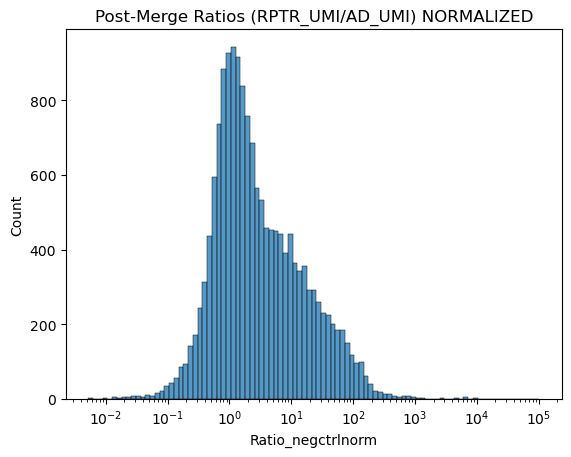

In [15]:
sns.histplot(merged_1_15_df, x='Ratio_negctrlnorm', log_scale=True)
plt.title('Post-Merge Ratios (RPTR_UMI/AD_UMI) NORMALIZED')

In [16]:
merged_1_15_df

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm
0,ACTTAGTGGGTATC,113,5637.0,TATAGAATTAC,GTTCAAGATTCTCCAGCTGAAGCTTCTGATGAAGTTGAAACTGGTC...,860,11407.0,0.131395,0.952517
1,TTACAATAGACTCT,3551,203926.0,CCGTAGGTTAA,TTTGATTTGGTTGGTGAAGAAGGTGCTGGTAAACCATTGTCTCAAT...,954,12346.0,3.722222,26.983303
2,CTCCTAGCCACATA,180,9289.0,AAGCGACAACA,CAAGATCCATATATGTCTGCTCCAAATTCTACTGCATTTACTGCTT...,74,1092.0,2.432432,17.633300
3,ATGAGTCCATTTCA,100,4895.0,TTTCCCTTCTG,GCTAGACCACCAGTTCCACCATTTCCACATTCTACTGGTTCTGTTC...,182,2380.0,0.549451,3.983102
4,CGGCACCATCTGGA,163,8862.0,GCCCCCGTCAC,TTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAAT...,1549,19854.0,0.105229,0.762832
...,...,...,...,...,...,...,...,...,...
16371,TGTACGGTTGTTCG,2,98.0,TAACCATTGTT,CATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTGTTAGATCTA...,2,22.0,1.000000,7.249246
16372,CTCACCCGGTGAAA,19,1183.0,GACGCCGGCGG,TTGGGTTATGCTACTTCTCCAGCTTCATTCTCTTATAGATCTCCAT...,4,4.0,4.750000,34.433916
16373,TCAAAACTGAATTA,7,367.0,TACGTGAACAA,CCAACTCATTCTGGTGCTAGAATTTCTACTGTTCCACAACCACCAC...,5,63.0,1.400000,10.148944
16374,CACTCCCGTATCAT,19,597.0,CATTGACATCG,TGGCCATCTCCACCAGCTCCACAACCATCTAGACATCATTTGAATA...,1,34.0,19.000000,137.735665


### AD DBs

In [17]:
conn_ad = duckdb.connect(ad_1_15)
conn_ad.sql('SHOW ALL TABLES')

┌──────────┬─────────┬────────────┬──────────────────────────────┬─────────────────────────────────────┬───────────┐
│ database │ schema  │    name    │         column_names         │            column_types             │ temporary │
│ varchar  │ varchar │  varchar   │          varchar[]           │              varchar[]              │  boolean  │
├──────────┼─────────┼────────────┼──────────────────────────────┼─────────────────────────────────────┼───────────┤
│ AD_1_15  │ main    │ ad_summary │ [Barcode, Tile, UMIs, Reads] │ [VARCHAR, VARCHAR, BIGINT, HUGEINT] │ false     │
│ AD_1_15  │ main    │ umi_counts │ [UMI, Barcode, Tile, Count]  │ [VARCHAR, VARCHAR, VARCHAR, BIGINT] │ false     │
└──────────┴─────────┴────────────┴──────────────────────────────┴─────────────────────────────────────┴───────────┘

In [15]:
conn_ad.sql("SELECT COUNT(DISTINCT Tile) FROM ad_summary")

┌──────────────────────┐
│ count(DISTINCT Tile) │
│        int64         │
├──────────────────────┤
│              2262298 │
└──────────────────────┘

In [ ]:
AD_1_15_df = conn_ad.sql("SELECT * FROM ad_summary").df()
AD_1_15_df

In [16]:
conn_ad.close()

# Final draft test

In [10]:
def bc_grouping(db_path, is_rptr=True):
    try:
        conn = duckdb.connect(db_path)
        print('connected to db')
        if is_rptr:
            group_query = f"""
                SELECT Barcode, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode
            """
            new_table = "rptr_summary"
        else:
            group_query = f"""
                SELECT Barcode, Tile, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode, Tile
            """
            new_table = "ad_summary"

        conn.execute(f"CREATE OR REPLACE TABLE {new_table} AS {group_query}")
        print('summary table created')
        row_count = conn.execute(f"SELECT COUNT(*) FROM {new_table}").fetchone()[0]
        print(f"[GROUP] Wrote {row_count} rows to {new_table} in {db_path}")

    except Exception as e:
        print(f"[ERROR] While filtering and grouping {db_path}: {e}")

    finally:
        conn.close()


def perform_lookup(rptr_db_path, lookup_db_path):
    try:
        rptr_conn = duckdb.connect(rptr_db_path)
        rptr_conn.execute(f"ATTACH DATABASE '{lookup_db_path}' AS lookup_db")

        total_rptr_barcodes = rptr_conn.execute("SELECT COUNT(*) FROM rptr_summary").fetchone()[0]

        rptr_conn.execute("""
            CREATE OR REPLACE TABLE rptr_lookup_joined AS
            SELECT 
                r.Barcode, r.UMIs, r.Reads,
                l.AD,
                l.AD_BC,
                l.AD || '-' || l.AD_BC AS AD_ADBC
            FROM rptr_summary r
            INNER JOIN lookup_db.A10_2_T_NODBLMAP_20240422 l
            ON r.Barcode = l.RPTR_BC;
        """)

        matched_count = rptr_conn.execute("SELECT COUNT(*) FROM rptr_lookup_joined").fetchone()[0]
        print(f"[LOOKUP JOIN] Matched {matched_count} of {total_rptr_barcodes} RPTR barcodes "
              f"({total_rptr_barcodes - matched_count} unmatched, discarded in join).")

    except Exception as e:
        print(f"[ERROR] During lookup join in {rptr_db_path}: {e}")

    finally:
        rptr_conn.close()


def join_rptr_ad(rptr_db, ad_db, output_db, out_table):
    try:
        conn_out = duckdb.connect(output_db)

        # Attach RPTR and AD databases
        conn_out.execute(f"ATTACH DATABASE '{rptr_db}' AS rptr_db")
        conn_out.execute(f"ATTACH DATABASE '{ad_db}' AS ad_db")

        # Perform join and save
        conn_out.execute(f"""
            CREATE OR REPLACE TABLE {out_table} AS
            SELECT 
                r.Barcode AS RPTR_BC,
                r.UMIs AS RPTR_UMIs,
                r.Reads AS RPTR_Reads,
                a.Barcode AS AD_BC,
                a.Tile,
                a.UMIs AS AD_UMIs,
                a.Reads AS AD_Reads
            FROM rptr_db.rptr_lookup_joined r
            INNER JOIN ad_db.ad_summary a
            ON r.AD_ADBC = a.Tile || '-' || a.Barcode;
        """)

        joined_count = conn_out.execute(f"SELECT COUNT(*) FROM {out_table}").fetchone()[0]
        print(f"[JOIN FINAL] Joined entries: {joined_count}")

    except Exception as e:
        print(f"[ERROR] During final join: {e}")

    finally:
        conn_out.close()



In [17]:
patterns = ["1_15"]
# negative controls
negctrls_fpath = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/Ciber2_iii/CZB_Sep2024/neg_controls.csv'
neg_controls_df = pd.read_csv(negctrls_fpath, usecols=['DNAseq'])
neg_controls = neg_controls_df['DNAseq'].to_list() # list of all negative controls
neg_controls[:5]

['GATGCTTTGTCTTCTTCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCT',
 'TCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCTAGACAATTGTTGGAA',
 'TTGAATGCTTATAGAGAAAAAGGTGGTTGTGTTTTGTTGATTCATAGAGATACTAAACAAGTTGTTGAATATTTGTTGCAAGATAAAACTAGACCAGCTTATAGAGAAGATATTGAAGAT',
 'GCTTTGCATAATACTTTGTTTCAATTGACTGGTTTGCCACATTCTTATTCTGCTGTTGAAACTGATCAAGCTGAACCAACTGTTAGAGAATTGACTAGAAGAGCTGATTTTGGTGGTGCT',
 'GCTCCAGCTCCACAACCATCTCCAGTTCAAAAACCAGTTGAAACTGAAGTTGCTGTTACTACTACTTCTTCTTCTTCTAGAAGAAAATCTGGTGGTTCTCCAGCTTCTGGTAGACATTCT']

In [20]:
rptr_dir = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed'
ad_dir = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed'
merged_dfs = {}
for pattern in patterns:
    print(pattern)
    rptr_db_ec = glob.glob(f"{rptr_dir}/RPTR_{pattern}_S*_R1_001.duckdb")[0]
    ad_db_ec = f"{ad_dir}/AD_{pattern}.fastq.gz.assembled.fastq.duckdb"
    save_table_as = f'merged_{pattern}'

    # # create databases
    # bc_grouping(rptr_db_ec, is_rptr=True) # creates rptr_summary
    # bc_grouping(ad_db_ec, is_rptr=False) # creates ad_summary
    # perform_lookup(rptr_db_ec, ec_lookup) # creates rptr_lookup_joined
    # join_rptr_ad(rptr_db_ec, ad_db_ec, ec_output, save_table_as) # creates/opens database (save_db_to = 'post_merge.db') and saves that time point/sample as save_table_as = f'merged_{pattern}'

    if glob.glob(ec_output):
        conn = duckdb.connect(ec_output)
        df = conn.sql(f"SELECT * FROM {save_table_as}").df()
        df['Ratio'] = df['RPTR_UMIs'] / df['AD_UMIs']
        neg_control_mean = df[df['Tile'].isin(neg_controls)]['Ratio'].mean()
        df['Ratio_negctrlnorm'] = df['Ratio']/neg_control_mean
        merged_dfs[pattern] = df
        conn.close()


1_15


In [21]:
merged_dfs['1_15']

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm
0,ACTCTAATGGCAAT,8,303.0,CCTTACCCTAG,TATGATCATTTGGGTGTTATTTCTTATAATAGGAAACAAAGAGCTG...,28,335.0,0.285714,2.071213
1,TGAAGGAAACCAGC,491,24768.0,CAGTTGGTCAA,TTGTTGCAAGATGTTATGGAGAATAAAGGTCATGGTTATGTCTTCT...,4799,70437.0,0.102313,0.741692
2,TTCACCGACTTTGC,134,6142.0,CAAGAATAATA,AAGAGAGAAATTGAACAACCAGAAATGATTGAAATTAAGAGAGCTG...,445,6133.0,0.301124,2.182919
3,TGCCGTATTTCACC,76,4140.0,GCTGCTCGGTC,CCATTTGAACCATCTTTGGATGCTGATATTCAAGATATCTTAAATT...,94,1287.0,0.808511,5.861092
4,ATATTCATTAAGAT,6641,367954.0,TTCCCGCTGAA,CCATTTGATTCTCCAGGTTACTTCTCTCATGATCCATCTCCAATGT...,620,8829.0,10.711290,77.648773
...,...,...,...,...,...,...,...,...,...
16371,TAAAATCGATAATT,19,788.0,AACGGTAATAA,CATCCATCTCAACCACCATTGGTTGGTCCAGTTAATTCTTCTATTG...,17,178.0,1.117647,8.102098
16372,TTGACTTTCACCCG,3,212.0,GGCGTGACTCC,GGTGGTTCTGAAGATCATTCTAATTTGGATTCTTCTGTTTCTCCAT...,20,203.0,0.150000,1.087387
16373,GACCATTGTGCAAG,130,5930.0,ACATCAGTATG,TCTCCATCTGAAGGTTATGAAACTTCTCCATTGTTTAATACTAATG...,11,142.0,11.818182,85.672901
16374,ATAAGAACAAATTA,97,5270.0,AGCACCAATGT,TTGAGAACTAACTTTGATGATCCAGAGTTCTTTGACTTTACTGAAG...,7,127.0,13.857143,100.453831


# Switch to adbc mapping?

In [8]:
def bc_grouping(db_path, is_rptr=True):
    try:
        conn = duckdb.connect(db_path)
        print('connected to db')
        if is_rptr:
            group_query = f"""
                SELECT Barcode, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode
            """
            new_table = "rptr_summary"
        else:
            group_query = f"""
                SELECT Barcode, Tile, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode, Tile
            """
            new_table = "ad_summary"

        conn.execute(f"CREATE OR REPLACE TABLE {new_table} AS {group_query}")
        print('summary table created')
        row_count = conn.execute(f"SELECT COUNT(*) FROM {new_table}").fetchone()[0]
        print(f"[GROUP] Wrote {row_count} rows to {new_table} in {db_path}")

    except Exception as e:
        print(f"[ERROR] While filtering and grouping {db_path}: {e}")

    finally:
        conn.close()


def perform_lookup_ADtoRPTR(ad_db_path, lookup_db_path):
    try:
        ad_conn = duckdb.connect(ad_db_path)
        ad_conn.execute(f"ATTACH DATABASE '{lookup_db_path}' AS lookup_db")

        total_ad_barcodes = ad_conn.execute("SELECT COUNT(*) FROM ad_summary").fetchone()[0]

        ad_conn.execute("""
            CREATE OR REPLACE TABLE ad_lookup_joined AS
            SELECT 
                a.UMIs, 
                a.Reads,
                a.Barcode,
                a.Tile,
                l.AD,
                l.AD_BC,
                l.AD || '-' || l.AD_BC AS AD_ADBC
            FROM ad_summary a
            INNER JOIN lookup_db.A10_2_T_NODBLMAP_20240422 l
            ON a.Tile || '-' || a.Barcode = l.AD || '-' || l.AD_BC
        """)

        matched_count = ad_conn.execute("SELECT COUNT(*) FROM ad_lookup_joined").fetchone()[0]
        print(f"[LOOKUP JOIN] Matched {matched_count} of {total_ad_barcodes} AD barcodes "
              f"({total_ad_barcodes - matched_count} unmatched, discarded in join).")

    except Exception as e:
        print(f"[ERROR] During lookup join in {ad_db_path}: {e}")

    finally:
        ad_conn.close()



def join_rptr_ad(rptr_db, ad_db, output_db, out_table):
    try:
        conn_out = duckdb.connect(output_db)

        # Attach RPTR and AD databases
        conn_out.execute(f"ATTACH DATABASE '{rptr_db}' AS rptr_db")
        conn_out.execute(f"ATTACH DATABASE '{ad_db}' AS ad_db")

        # Perform join and save
        conn_out.execute(f"""
            CREATE OR REPLACE TABLE {out_table} AS
            SELECT 
                r.Barcode AS RPTR_BC,
                r.UMIs AS RPTR_UMIs,
                r.Reads AS RPTR_Reads,
                a.Barcode AS AD_BC,
                a.Tile,
                a.UMIs AS AD_UMIs,
                a.Reads AS AD_Reads
            FROM rptr_db.rptr_lookup_joined r
            INNER JOIN ad_db.ad_summary a
            ON r.AD_ADBC = a.Tile || '-' || a.Barcode;
        """)

        joined_count = conn_out.execute(f"SELECT COUNT(*) FROM {out_table}").fetchone()[0]
        print(f"[JOIN FINAL] Joined entries: {joined_count}")

    except Exception as e:
        print(f"[ERROR] During final join: {e}")

    finally:
        conn_out.close()



In [5]:
ec_lookup = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/A10_sequencing/v2/current/analysis2_updated.db'
rptr_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb'
ad_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb'
# ec_output = 'test_1_15_merge.db'

In [9]:
# create databases
# # bc_grouping(rptr_db_ec, is_rptr=True) # creates rptr_summary
# # bc_grouping(ad_db_ec, is_rptr=False) # creates ad_summary
perform_lookup_ADtoRPTR(ad_1_15, ec_lookup) # creates rptr_lookup_joined
# join_rptr_ad(rptr_db_ec, ad_db_ec, ec_output, save_table_as) # creates/opens database (save_db_to = 'post_merge.db') and saves that time point/sample as save_table_as = f'merged_{pattern}'


[LOOKUP JOIN] Matched 20671 of 2761835 AD barcodes (2741164 unmatched, discarded in join).


In [10]:
conn_ad = duckdb.connect(ad_1_15)

In [12]:
AD_1_15_lkp_df = conn_ad.sql("SELECT * FROM ad_lookup_joined").df()
AD_1_15_lkp_df

,UMIs,Reads,Barcode,Tile,AD,AD_BC,AD_ADBC
0,433,6421.0,CTTCTGCTTTC,ATGACTCATACTTTGAAAGGTGCTACTTTGAGAGCTGGTTTGCACT...,ATGACTCATACTTTGAAAGGTGCTACTTTGAGAGCTGGTTTGCACT...,CTTCTGCTTTC,ATGACTCATACTTTGAAAGGTGCTACTTTGAGAGCTGGTTTGCACT...
1,1005,12746.0,GAACTAGTCAA,TCTTATGAAGTTTCTCCAAATTATGGTGGTTCTGACTTTGATCATG...,TCTTATGAAGTTTCTCCAAATTATGGTGGTTCTGACTTTGATCATG...,GAACTAGTCAA,TCTTATGAAGTTTCTCCAAATTATGGTGGTTCTGACTTTGATCATG...
2,148,2103.0,CTAACATATTG,TCTACTGCTTCTCCAGCTGCTGTTCCAAGATTCTTTGAAGCTTATG...,TCTACTGCTTCTCCAGCTGCTGTTCCAAGATTCTTTGAAGCTTATG...,CTAACATATTG,TCTACTGCTTCTCCAGCTGCTGTTCCAAGATTCTTTGAAGCTTATG...
3,699,10086.0,GTAAACTGGAT,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...,GTAAACTGGAT,CCATCTGACTTTCCATTTCCAGAAACTTTGACTTCTTCTACTGCTT...
4,1486,20510.0,GAATTTCTCCC,AGAAGGAAATCTGGTACTTCTCCATCTACTAGACATTCTTCTGTTG...,AGAAGGAAATCTGGTACTTCTCCATCTACTAGACATTCTTCTGTTG...,GAATTTCTCCC,AGAAGGAAATCTGGTACTTCTCCATCTACTAGACATTCTTCTGTTG...
...,...,...,...,...,...,...,...
20666,1,29.0,CCCGGACTTTG,CCAGTTCCATTGTTTCATTCTGCTGGTAATCCACCACAGAATCAAC...,CCAGTTCCATTGTTTCATTCTGCTGGTAATCCACCACAGAATCAAC...,CCCGGACTTTG,CCAGTTCCATTGTTTCATTCTGCTGGTAATCCACCACAGAATCAAC...
20667,2,10.0,ATAACCGAAGA,TCTTCTGCTGGTTCTGTTCAGAAGAAATCTGATAAATTGGATAGAT...,TCTTCTGCTGGTTCTGTTCAGAAGAAATCTGATAAATTGGATAGAT...,ATAACCGAAGA,TCTTCTGCTGGTTCTGTTCAGAAGAAATCTGATAAATTGGATAGAT...
20668,2,2.0,GAATCACTTAG,TTGGATGCTTTGGATCAATTGTTCTTGGATGCTACTGCTAATGTTG...,TTGGATGCTTTGGATCAATTGTTCTTGGATGCTACTGCTAATGTTG...,GAATCACTTAG,TTGGATGCTTTGGATCAATTGTTCTTGGATGCTACTGCTAATGTTG...
20669,1,1.0,GGAATAAGATA,GAAATTGTTTCTGGTTTGGGTTATTCTACTTCTCCATCTTCATTCT...,GAAATTGTTTCTGGTTTGGGTTATTCTACTTCTCCATCTTCATTCT...,GGAATAAGATA,GAAATTGTTTCTGGTTTGGGTTATTCTACTTCTCCATCTTCATTCT...


/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Reads', ylabel='Count'>

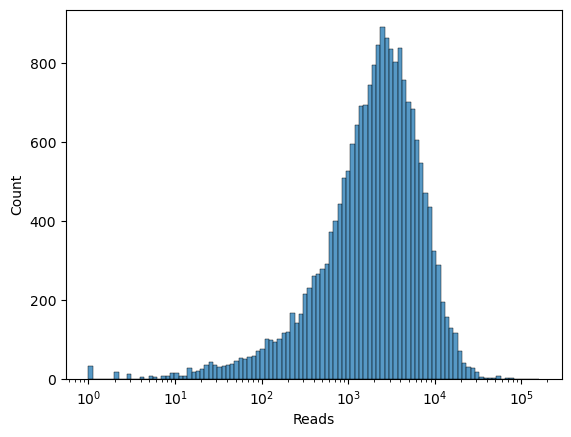

In [13]:
sns.histplot(AD_1_15_lkp_df, x='Reads', log_scale=True)

In [15]:
conn_ad.sql("""
SELECT Barcode, Tile, COUNT(*) AS entries
FROM ad_lookup_joined
GROUP BY Barcode, Tile
HAVING COUNT(*) > 1
ORDER BY entries DESC;


""")

┌─────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│   Barcode   │                                                           Tile                                                           │ entries │
│   varchar   │                                                         varchar                                                          │  int64  │
├─────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ CGGCACTCGAG │ TCTGCTTTGACTATTTCATTTGATGTTACTTCATTTACTACTGATAATCAACATCAACCATGGTTGCCATCTCCACCACCACAATTGCAACCACATTTGGCTTCTAATTTGTTGAATGAT │       5 │
│ GATCACAATGG │ TCTAGAGCTAGGAAATTGCAAAGAATGAATCAATTGGAAGATAAAGTTAAAGAATTGTTGCAAAGAAATTCTGATTTGGAGAATGAAGTTACTAGATTGAGATCTATGTTGGGTTCTCAA │       4 │
│ AAACAGATACA │ GCTCCATCTGCTCATCAACATTCATTTCAATCTCCACCACAACAAGACTTTGTCTTGTTTGATTCTCCACAACCAACTAGAACTACTGTT

In [16]:
conn_ad.close()

that was good info but switching mapping doesn't solve anything

# Are 16k tiles also in ciberv2_iii?

In [17]:
# ec_lookup = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/A10_sequencing/v2/current/analysis2_updated.db'
# rptr_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb'
# ad_1_15 = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_15.fastq.gz.assembled.fastq.duckdb'
ec_output = 'test_1_15_merge.db'

In [18]:
conntest = duckdb.connect(ec_output)
conntest.sql("SHOW ALL TABLES")

┌─────────────────┬─────────┬────────────────┬──────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────┬───────────┐
│    database     │ schema  │      name      │                           column_names                           │                         column_types                          │ temporary │
│     varchar     │ varchar │    varchar     │                            varchar[]                             │                           varchar[]                           │  boolean  │
├─────────────────┼─────────┼────────────────┼──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┼───────────┤
│ test_1_15_merge │ main    │ final_analysis │ [RPTR_BC, RPTR_UMIs, RPTR_Reads, AD_BC, Tile, AD_UMIs, AD_Reads] │ [VARCHAR, BIGINT, HUGEINT, VARCHAR, VARCHAR, BIGINT, HUGEINT] │ false     │
│ test_1_15_merge │ main    │ merged_1_15    │ [RP

In [ ]:
umi_1_15_all = conntest.sql(""" SELECT * FROM merged_1_15""").df()

In [19]:
conntest.close()

# Before trying it on the single df, try on total:

In [20]:
alldata = pd.read_csv('rawdata_UMIs_normalized_20250415.csv')
alldata

,Unnamed: 0,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library,Time,sample
0,0,CTTGTTGGATCAAA,2,720.0,ATCGATCCGAA,TGGTATTCTTTGTTTCCACCAACTACTACTTCTTCTGAAGATTCTC...,9,87.0,0.222222,1.054749,2_0,0,2
1,1,CTGACGAATCGTAC,2,96.0,ACTATGTGTTA,GCTGCTGTTTCTACTAAATTGGAAGCTCCAGCTACTACTCATTTGA...,14,121.0,0.142857,0.678053,2_0,0,2
2,2,CGACAAGAGTGATT,29,2709.0,GGACGCACACG,ATGACATTTGATTCTTCTAATTTGAATGCTGCTCCAGCTTCTTCTG...,7,70.0,4.142857,19.663531,2_0,0,2
3,3,GTGGCAATAACGGA,1,18.0,CATGATAGGTC,ATTGAAAGAGATGCTAGAAGAGAATGTTGTGCTCCACAATCTAATT...,4,39.0,0.250000,1.186592,2_0,0,2
4,4,GAGCATCCAGACGA,48,4093.0,CCTCGACATAG,CATTCTTCTTTGAGACCATCTGATGAAGCTTGTCCATTGTCTACTG...,2,3.0,24.000000,113.912870,2_0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315083,315083,CTCAGTGTGAGTGT,9,152.0,CCGTGCCCCCG,TCTGATAATTCTAATCCATTGAATGCTTCATTCTTGATTCCACAAT...,8,139.0,1.125000,1.517782,3_240,240,3
315084,315084,CACTCCCGTGTTTC,729,13930.0,TCTTTCCTCCG,GTTGTTACTACTTCTGCTGTTGTTACTACTTCTGCTGCTTCTCAAG...,4,33.0,182.250000,245.880634,3_240,240,3
315085,315085,TAACAAATTATGGC,3,14.0,CAGGTTCAGAG,GATTATTCTCCATTGACTGGTGTTCATGATACTTCTTCTCCATCTA...,3,13.0,1.000000,1.349139,3_240,240,3
315086,315086,GTATCAACCACCAC,739,14493.0,GCCTTCACCCG,CCACCACAACCAACTGCTCAGAATTTAAATTCTAATAATGATAATA...,2,6.0,369.500000,498.506964,3_240,240,3


In [26]:
umi_rbcs = alldata['RPTR_BC'].value_counts().to_frame().reset_index()
umi_rbcs

,RPTR_BC,count
0,CTCACCCGGTGAAA,62
1,CCGCTAAGCCTCGG,38
2,AGGGGTGCATAAGC,38
3,TGAGAGCTACCGTC,37
4,CCCGTTCTCCCGCC,34
...,...,...
17689,GAGCCCTTCTTGGA,1
17690,TATTCACATAGAAT,1
17691,CTAAACAAGTTGAA,1
17692,AGGCGTTGCCAGTA,1


In [22]:
alldata_ciber2iii = pd.read_csv('/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/Ciber2_iii/CZB_Sep2024/rawdata_normalized_20250326.csv')
alldata_ciber2iii

,Unnamed: 0,BCs,count_r,Allreads_r,Tile-AD,count_a,Library_a,Allreads_a,R_normalized,A_normalized,Ratio,Tile,AD,Library,R_norm_rpm,A_norm_rpm,Ratio_negCTRLnorm,Time,sample
0,0,GGAGGGGTCAGAAG,30178,25023784,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,21180,AD_3_0,32971640,1.205973e-03,0.000642,1.877379,TCTTCTTCATTTGGTTTGTCTGGTAATTCTTCTCAACATAGATTGT...,CGCGGCTACAA,AD_3_0,12059.726858,6423.702309,2.215195,0,3
1,1,CCCCAGACTCGTTG,20130,25023784,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,36030,AD_3_0,32971640,8.044347e-04,0.001093,0.736151,AGACCAGCTAGACCACCAGTTCCATTGTTCTCTCAATCTACTGGTT...,TCCTAAGCTCG,AD_3_0,8044.346930,10927.572908,0.868614,0,3
2,2,TTAAACCTTCGTCG,17807,25023784,CAAGGTGAACCAATGTTAAATTCTTCTAATGATTGGTTCTCTTTGT...,21205,AD_3_0,32971640,7.116030e-04,0.000643,1.106471,CAAGGTGAACCAATGTTAAATTCTTCTAATGATTGGTTCTCTTTGT...,GTCCGTAGGGA,AD_3_0,7116.030094,6431.284583,1.305569,0,3
3,3,TATGTTGTAGCTTA,17336,25023784,TTGGGTGTTATTACTTATAATAGGAAACAAAGAGCTACTCCATTGA...,26415,AD_3_0,32971640,6.927809e-04,0.000801,0.864741,TTGGGTGTTATTACTTATAATAGGAAACAAAGAGCTACTCCATTGA...,CTACGGAACTC,AD_3_0,6927.809159,8011.430429,1.020342,0,3
4,4,TGGCTACCAAACAA,15459,25023784,GTTGAATCTATGTCTGCTCCACCATCTGGTGCTTATACTGATTTGA...,18042,AD_3_0,32971640,6.177723e-04,0.000547,1.128975,GTTGAATCTATGTCTGCTCCACCATCTGGTGCTTATACTGATTTGA...,TCATTATGAGC,AD_3_0,6177.722762,5471.975310,1.332122,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310536,310536,CTGGCGAGAGAATA,10,29401118,AGAATTGGTTCTGCTTATCATGGTCAACAACAACATAGACCACATT...,33,AD_4_240,31347777,3.401231e-07,0.000001,0.323094,AGAATTGGTTCTGCTTATCATGGTCAACAACAACATAGACCACATT...,CCTATTCTTTC,AD_4_240,3.401231,10.527062,1.279538,240,4
310537,310537,AATATAAACTGGGC,10,29401118,TCTTCTACTTCTGGTGTTAGGAAGAGAACTAATCCATTGCCACCAA...,43,AD_4_240,31347777,3.401231e-07,0.000001,0.247956,TCTTCTACTTCTGGTGTTAGGAAGAGAACTAATCCATTGCCACCAA...,ACGTAATGATA,AD_4_240,3.401231,13.717081,0.981971,240,4
310538,310538,GTAGGCGGTTAAAA,10,29401118,GCTCAAGGTCATTCTGGTATTACTAGATCTACTCCAGCTTCTGGTA...,67,AD_4_240,31347777,3.401231e-07,0.000002,0.159136,GCTCAAGGTCATTCTGGTATTACTAGATCTACTCCAGCTTCTGGTA...,CATTTCAGAGC,AD_4_240,3.401231,21.373126,0.630220,240,4
310539,310539,TTCTACGATGTCCC,10,29401118,ACTTTGAGATCTTCTCCATCTTCTCAAACTCATGCTTTGAGAAGAT...,166,AD_4_240,31347777,3.401231e-07,0.000005,0.064230,ACTTTGAGATCTTCTCCATCTTCTCAAACTCATGCTTTGAGAAGAT...,ACCGCCCGGTC,AD_4_240,3.401231,52.954313,0.254366,240,4


In [27]:
c2iii_rbcs = alldata_ciber2iii['BCs'].value_counts().to_frame().reset_index()
c2iii_rbcs

,BCs,count
0,AGGGGTGCATAAGC,42
1,CCGCTAAGCCTCGG,42
2,CTCACCCGGTGAAA,22
3,TCAACTCGCATATA,21
4,TAGACATTATGCGT,21
...,...,...
15382,GCATGAAAAGTTGA,1
15383,AAAGAACGATAGCC,1
15384,TGCAGCTAATCACA,1
15385,TGCCGCATCAAGTT,1


In [28]:
compare_umivc2iii = umi_rbcs.merge(c2iii_rbcs, left_on='RPTR_BC', right_on='BCs', how='left')
compare_umivc2iii

,RPTR_BC,count_x,BCs,count_y
0,CTCACCCGGTGAAA,62,CTCACCCGGTGAAA,22.0
1,CCGCTAAGCCTCGG,38,CCGCTAAGCCTCGG,42.0
2,AGGGGTGCATAAGC,38,AGGGGTGCATAAGC,42.0
3,TGAGAGCTACCGTC,37,TGAGAGCTACCGTC,21.0
4,CCCGTTCTCCCGCC,34,NaN,NaN
...,...,...,...,...
17689,GAGCCCTTCTTGGA,1,NaN,NaN
17690,TATTCACATAGAAT,1,NaN,NaN
17691,CTAAACAAGTTGAA,1,NaN,NaN
17692,AGGCGTTGCCAGTA,1,NaN,NaN


In [30]:
compare_umivc2iii[compare_umivc2iii.isna().any(axis=1)]

,RPTR_BC,count_x,BCs,count_y
4,CCCGTTCTCCCGCC,34,NaN,NaN
14,CACTCCCGTGTTTC,25,NaN,NaN
22,TTCTGTTTGGCAGT,22,NaN,NaN
32,TAGCCAACTAAAAT,20,NaN,NaN
36,CAGTCAATGTAACT,20,NaN,NaN
...,...,...,...,...
17689,GAGCCCTTCTTGGA,1,NaN,NaN
17690,TATTCACATAGAAT,1,NaN,NaN
17691,CTAAACAAGTTGAA,1,NaN,NaN
17692,AGGCGTTGCCAGTA,1,NaN,NaN


In [32]:
compare_umivc2iii_right = umi_rbcs.merge(c2iii_rbcs, left_on='RPTR_BC', right_on='BCs', how='right')
compare_umivc2iii_right[compare_umivc2iii_right.isna().any(axis=1)].shape

(34, 4)